In [1]:
pip install icechunk

Note: you may need to restart the kernel to use updated packages.


In [7]:
import s3fs
import fsspec
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import icechunk
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [8]:
storage = icechunk.s3_storage(
    bucket='carbonplan-srm', prefix='input/tensor/CESM-G6-1.5K/icechunk/icechunk', from_env=True)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session("main")
ds_g6 = xr.open_zarr(session.store, consolidated=False)

In [4]:
storage = icechunk.s3_storage(
    bucket='carbonplan-srm', prefix='input/tensor/CESM2-WACCM-SSP245/icechunk/icechunk', from_env=True)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session("main")
ds_ssp = xr.open_zarr(session.store, consolidated=False)

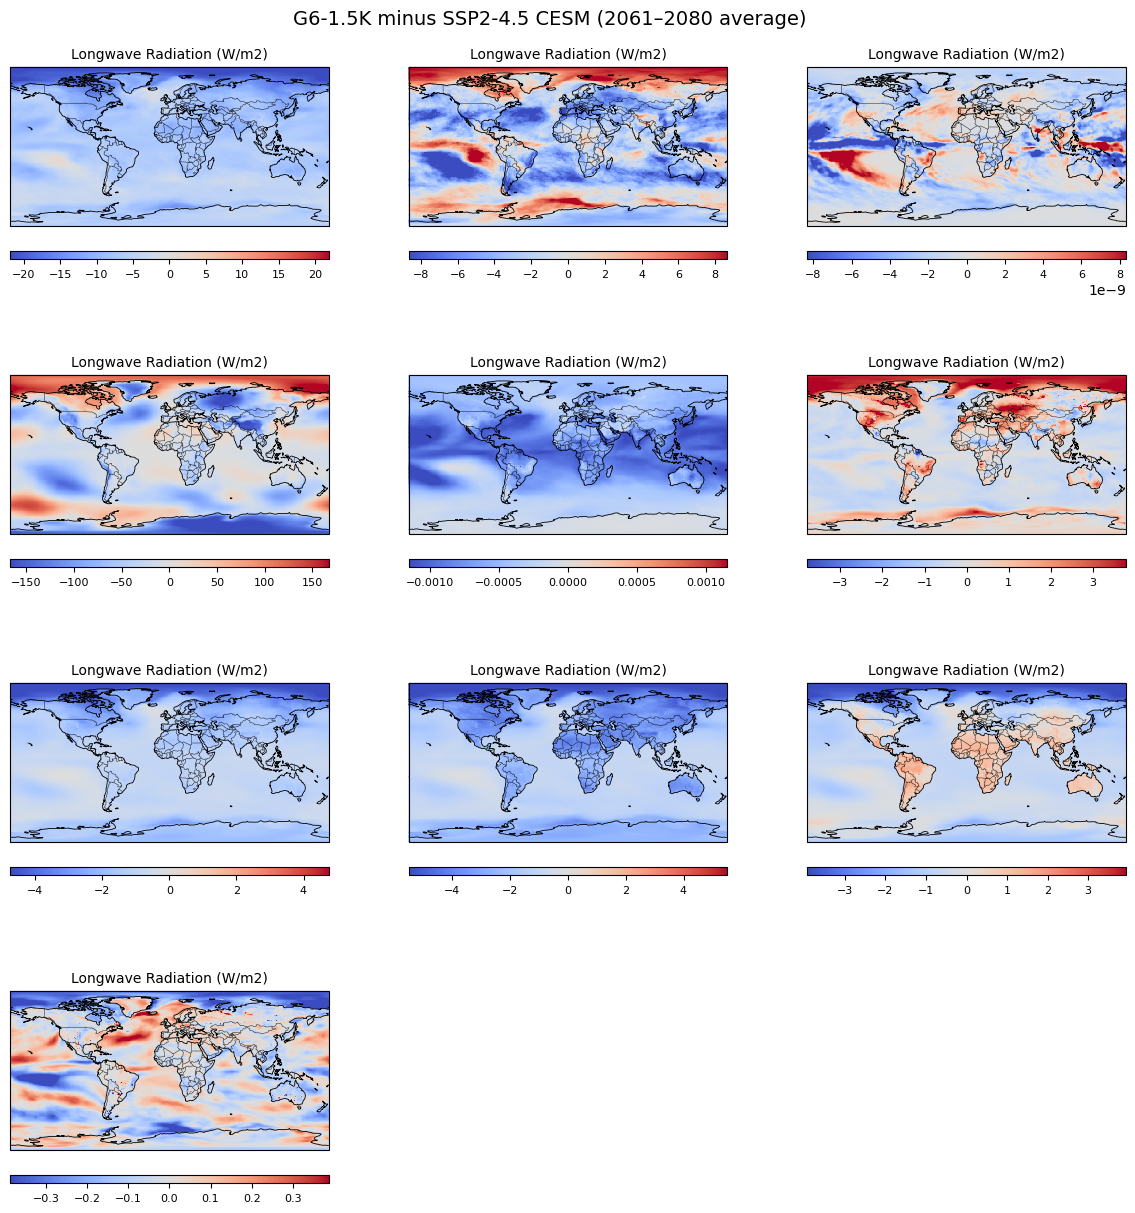

In [9]:
def to_lon180(ds):
    lon180 = xr.where(ds.lon > 180, ds.lon - 360, ds.lon)
    return ds.assign_coords(lon=lon180).sortby("lon")

ds_ssp = to_lon180(ds_ssp).sel(time=slice("2061-01-01", "2080-12-31"))
ds_g6  = to_lon180(ds_g6 ).sel(time=slice("2061-01-01", "2080-12-31"))

common_vars = sorted(set(ds_ssp.data_vars).intersection(ds_g6.data_vars))
ds_ssp = ds_ssp[common_vars]
ds_g6  = ds_g6[common_vars]

ssp_mean = ds_ssp.mean("time", keep_attrs=True)
g6_mean  = ds_g6.mean("time",  keep_attrs=True)

VARS = common_vars  

CUSTOM_TITLES = [
    "Longwave Radiation (W/m2)",
    "Shortwave Radiation (W/m2)",
    "Precipitation (m/s)",
    "Surface Pressure (Pa)",
    "Specific Humidity (kg/kg)",
    "Relative Humidity",
    "Surface Temperature (K)",
    "Minimum Temperature (K)",
    "Maximum Temperature (K)",
    "10m wind speed (m/s)",
]

n = len(VARS)
ncols = 3 if n >= 3 else n
nrows = int(np.ceil(n / ncols))

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(4.8*ncols, 4*nrows))
fig.subplots_adjust(wspace=0.25, hspace=0.0)

for i, v in enumerate(VARS, 1):
    da = dif[v]

    da_coarse = da.coarsen(lat=4, lon=4, boundary="trim").mean()
    qmin = float(da_coarse.quantile(0.02))
    qmax = float(da_coarse.quantile(0.98))
    lim = max(abs(qmin), abs(qmax))
    vmin, vmax = -lim, lim

    ax = fig.add_subplot(nrows, ncols, i, projection=proj)
    im = da.plot.pcolormesh(
        ax=ax, transform=proj, cmap="coolwarm", vmin=vmin, vmax=vmax,
        add_colorbar=False, rasterized=True
    )
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_global()
    ax.set_title(title, fontsize=10)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="5%", pad=0.25, axes_class=plt.Axes)
    cb = fig.colorbar(im, cax=cax, orientation="horizontal")
    cb.ax.tick_params(labelsize=8)

fig.suptitle("G6-1.5K minus SSP2-4.5 CESM (2061–2080 average)", fontsize=14, y=0.88)
fig.savefig("g6_minus_ssp_differences.png", dpi=600, bbox_inches="tight")